In [1]:
import os
import numpy as np
import scipy.io as sio
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
import sys
sys.path.append("..") 
from processing import  load_UCI_dataset, print_metrics, plot_regression_results

In [3]:
X_train, y_train, X_val, y_val, X_test, y_test = load_UCI_dataset(
    WINDOW_SIZE=625,
    STEP_SIZE=625
)

Total recordings: 12000
Train recordings: 9600
Validation recordings: 1200
Test recordings: 1200


100%|██████████| 9600/9600 [01:45<00:00, 91.40it/s] 


Skipped recordings: 96


100%|██████████| 1200/1200 [00:13<00:00, 89.13it/s]


Skipped recordings: 7


100%|██████████| 1200/1200 [00:13<00:00, 90.11it/s] 


Skipped recordings: 9


In [4]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (417030, 1, 625)
y_train: (417030, 2)
X_val: (52650, 1, 625)
y_val: (52650, 2)
X_test: (52863, 1, 625)
y_test: (52863, 2)


In [5]:
from sktime.transformations.panel.rocket import MiniRocket

rocket = MiniRocket(num_kernels=10000, random_state=42)

rocket.fit(X_train)

MiniRocket(random_state=42)

In [6]:
X_train_rocket = rocket.transform(X_train)
X_val_rocket = rocket.transform(X_val)
X_test_rocket = rocket.transform(X_test)

print("X_train_rocket:", X_train_rocket.shape)
print("X_val_rocket:", X_val_rocket.shape)
print("X_test_rocket:", X_test_rocket.shape)

X_train_rocket: (417030, 9996)
X_val_rocket: (52650, 9996)
X_test_rocket: (52863, 9996)


In [7]:
y_train_sbp = y_train[:, 0]
y_train_dbp = y_train[:, 1]

y_val_sbp = y_val[:, 0]
y_val_dbp = y_val[:, 1]

y_test_sbp = y_test[:, 0]
y_test_dbp = y_test[:, 1]

## RIDGE REGRESSION ##

In [8]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# Hyperparameter grid
param_grid = {
    "alpha": [0.01, 0.1, 1, 10, 100, 1000, 10000]
}

# =========================
# SBP
# =========================
grid_ridge_sbp = GridSearchCV(
    estimator=Ridge(),
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=3,
    n_jobs=2,
    verbose=1
)

grid_ridge_sbp.fit(
    X_train_rocket,
    y_train[:, 0]
)

print("Best SBP parameters:")
print(grid_ridge_sbp.best_params_)

print("Best SBP CV RMSE:")
print((-grid_ridge_sbp.best_score_) ** 0.5)


# =========================
# DBP
# =========================
grid_ridge_dbp = GridSearchCV(
    estimator=Ridge(),
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=3,
    n_jobs=2,
    verbose=1
)

grid_ridge_dbp.fit(
    X_train_rocket,
    y_train[:, 1]
)

print("\nBest DBP parameters:")
print(grid_ridge_dbp.best_params_)

print("Best DBP CV RMSE:")
print((-grid_ridge_dbp.best_score_) ** 0.5)

Fitting 3 folds for each of 7 candidates, totalling 21 fits


Best SBP parameters:
{'alpha': 10}
Best SBP CV RMSE:
17.619057543259743
Fitting 3 folds for each of 7 candidates, totalling 21 fits

Best DBP parameters:
{'alpha': 100}
Best DBP CV RMSE:
9.076129169839547


In [10]:
y_pred_sbp = grid_ridge_sbp.predict(X_test_rocket)
y_pred_dbp = grid_ridge_dbp.predict(X_test_rocket)

In [12]:
print("MiniRocket + Ridge — SBP")
print("------------------------")
print_metrics(y_test_sbp, y_pred_sbp)

print("\nMiniRocket + Ridge — DBP")
print("------------------------")
print_metrics(y_test_dbp, y_pred_dbp)

MiniRocket + Ridge — SBP
------------------------
RMSE: 17.4925
MSE : 305.9876
R²  : 0.4207
MAE : 13.2682

MiniRocket + Ridge — DBP
------------------------
RMSE: 8.9739
MSE : 80.5309
R²  : 0.3569
MAE : 6.5235


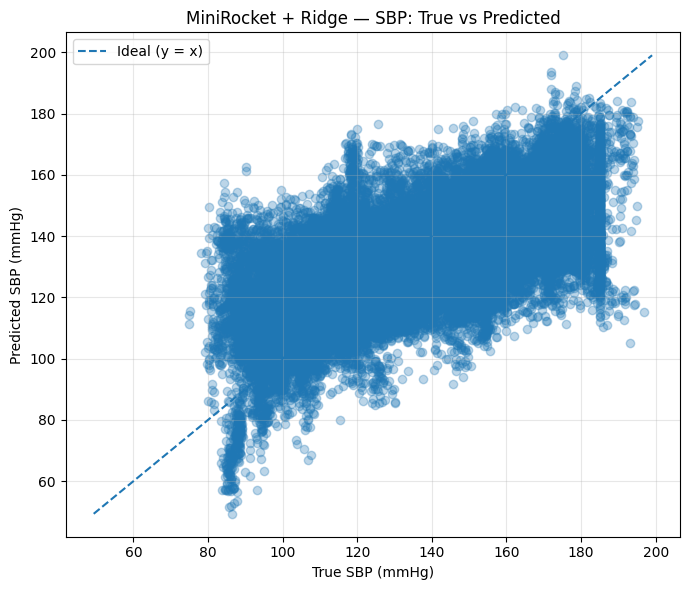

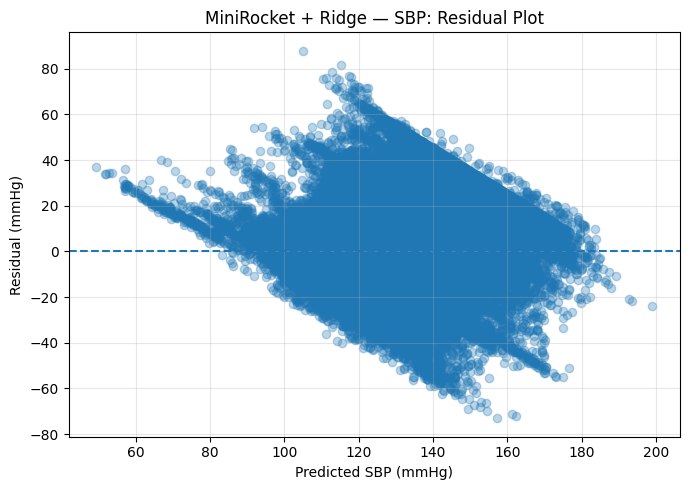

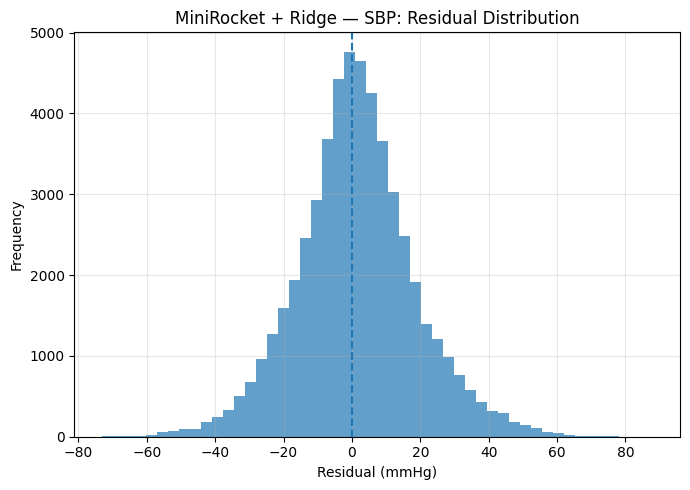

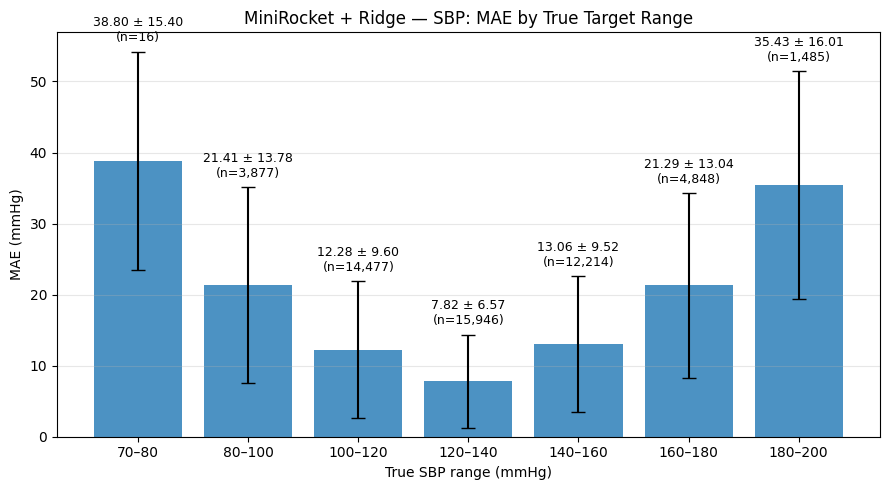

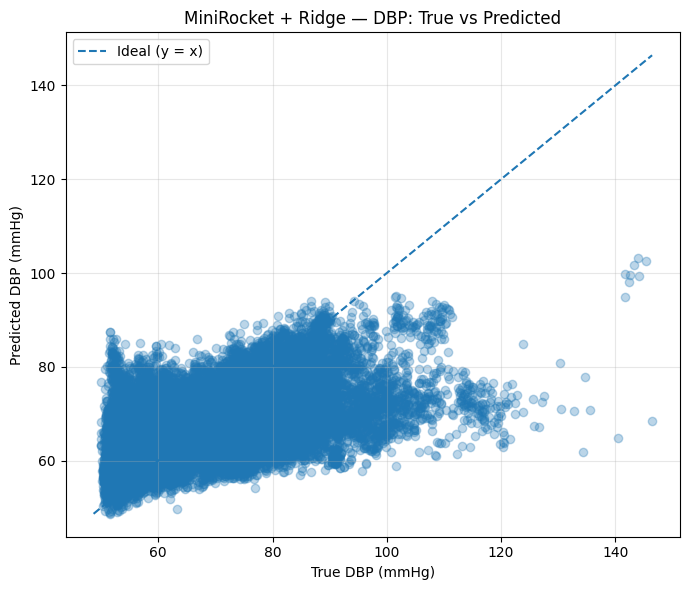

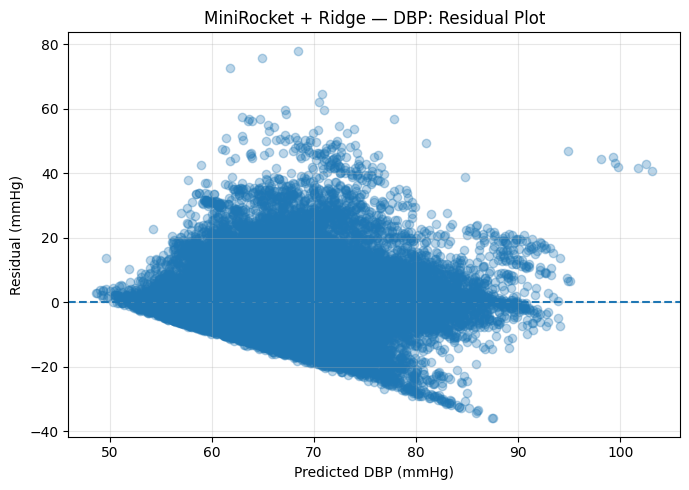

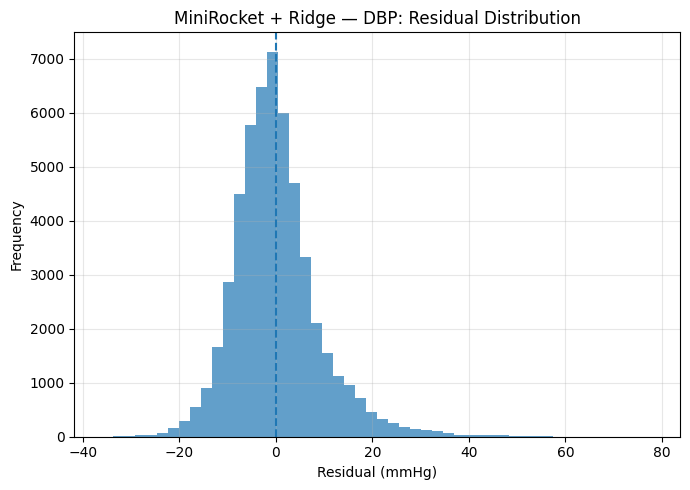

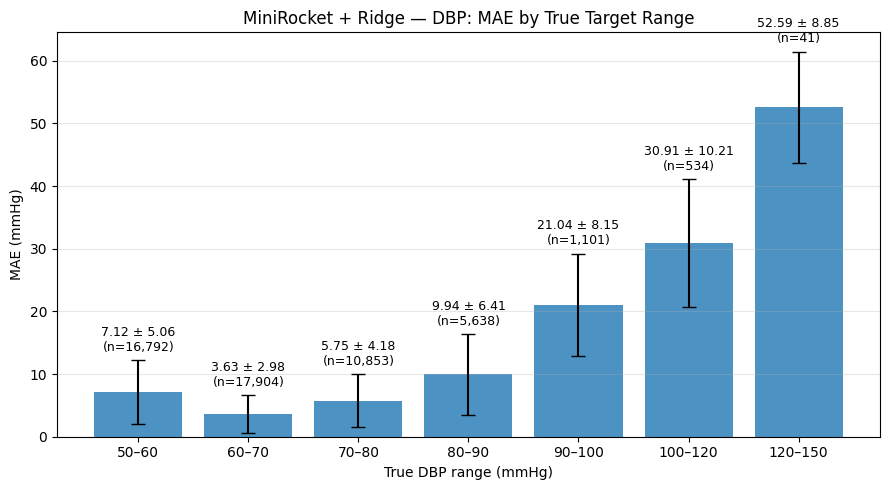

In [13]:
plot_regression_results(
    y_test_sbp,
    y_pred_sbp,
    "MiniRocket + Ridge",
    "SBP"
)

plot_regression_results(
    y_test_dbp,
    y_pred_dbp,
    "MiniRocket + Ridge",
    "DBP"
)

## ELASTIC NET ##

In [15]:
import numpy as np
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV

# --------------------------------------------------
# Use a subset ONLY for hyperparameter tuning due  to large dataset size
# --------------------------------------------------
rng = np.random.RandomState(42)

n_tune = min(20000, len(X_train_rocket))
tune_idx = rng.choice(
    len(X_train_rocket),
    size=n_tune,
    replace=False
)

X_tune = X_train_rocket.iloc[tune_idx] if hasattr(X_train_rocket, "iloc") else X_train_rocket[tune_idx]

y_tune_sbp = y_train[tune_idx, 0]
y_tune_dbp = y_train[tune_idx, 1]

print("ElasticNet tuning data:", X_tune.shape)

elastic_net = ElasticNet(
    max_iter=2000,
    random_state=42
)

param_grid_en = {
    "alpha": [0.001, 0.01, 0.1, 1.0],
    "l1_ratio": [0.1, 0.5, 0.9]
}

grid_en_sbp = GridSearchCV(
    estimator=elastic_net,
    param_grid=param_grid_en,
    scoring="neg_mean_squared_error",
    cv=3,
    n_jobs=2,
    verbose=1
)

grid_en_sbp.fit(X_tune, y_tune_sbp)

print("Best SBP parameters:", grid_en_sbp.best_params_)
print(
    "Best SBP CV RMSE:",
    np.sqrt(-grid_en_sbp.best_score_)
)


grid_en_dbp = GridSearchCV(
    estimator=elastic_net,
    param_grid=param_grid_en,
    scoring="neg_mean_squared_error",
    cv=3,
    n_jobs=2,
    verbose=1
)

grid_en_dbp.fit(X_tune, y_tune_dbp)

print("Best DBP parameters:", grid_en_dbp.best_params_)
print(
    "Best DBP CV RMSE:",
    np.sqrt(-grid_en_dbp.best_score_)
)

ElasticNet tuning data: (20000, 9996)
Fitting 3 folds for each of 12 candidates, totalling 36 fits


KeyboardInterrupt: 

In [ ]:
best_en_sbp = ElasticNet(
    alpha=grid_en_sbp.best_params_["alpha"],
    l1_ratio=grid_en_sbp.best_params_["l1_ratio"],
    max_iter=2000,
    random_state=42
)

best_en_dbp = ElasticNet(
    alpha=grid_en_dbp.best_params_["alpha"],
    l1_ratio=grid_en_dbp.best_params_["l1_ratio"],
    max_iter=2000,
    random_state=42
)

best_en_sbp.fit(X_train_rocket, y_train[:, 0])
best_en_dbp.fit(X_train_rocket, y_train[:, 1])

In [ ]:
y_pred_en_sbp = best_en_sbp.predict(X_test_rocket)
y_pred_en_dbp = best_en_dbp.predict(X_test_rocket)

In [ ]:
print("ElasticNet — SBP")
print("----------------")
print_metrics(y_test[:, 0], y_pred_en_sbp)

print("\nElasticNet — DBP")
print("----------------")
print_metrics(y_test[:, 1], y_pred_en_dbp)

In [ ]:
plot_regression_results(
    y_test_sbp,
    y_pred_en_sbp,
    "MiniRocket + ElasticNet",
    "SBP"
)

plot_regression_results(
    y_test_dbp,
    y_pred_en_dbp,
    "MiniRocket + ElasticNet",
    "DBP"
)

## LINEAR SVR ##

In [ ]:
from sklearn.svm import LinearSVR
rng = np.random.RandomState(42)

n_tune_svr = min(20000, len(X_train_rocket))

svr_idx = rng.choice(
    len(X_train_rocket),
    size=n_tune_svr,
    replace=False
)

X_tune_svr = (
    X_train_rocket.iloc[svr_idx]
    if hasattr(X_train_rocket, "iloc")
    else X_train_rocket[svr_idx]
)

y_tune_sbp_svr = y_train[svr_idx, 0]
y_tune_dbp_svr = y_train[svr_idx, 1]

print("SVR tuning data:", X_tune_svr.shape)

linear_svr = LinearSVR(
    max_iter=5000,
    random_state=42
)

param_grid_svr = {
    "C": [0.01, 0.1, 1.0, 10.0],
    "epsilon": [0.01, 0.1, 0.5]
}

In [ ]:
grid_svr_sbp = GridSearchCV(
    estimator=linear_svr,
    param_grid=param_grid_svr,
    scoring="neg_mean_squared_error",
    cv=3,
    n_jobs=2,
    verbose=1
)

grid_svr_sbp.fit(X_tune_svr, y_tune_sbp_svr)

print("Best SBP parameters:", grid_svr_sbp.best_params_)
print(
    "Best SBP CV RMSE:",
    np.sqrt(-grid_svr_sbp.best_score_)
)

grid_svr_dbp = GridSearchCV(
    estimator=linear_svr,
    param_grid=param_grid_svr,
    scoring="neg_mean_squared_error",
    cv=3,
    n_jobs=2,
    verbose=1
)

grid_svr_dbp.fit(X_tune_svr, y_tune_dbp_svr)

print("Best DBP parameters:", grid_svr_dbp.best_params_)
print(
    "Best DBP CV RMSE:",
    np.sqrt(-grid_svr_dbp.best_score_)
)

In [ ]:
best_svr_sbp = LinearSVR(
    C=grid_svr_sbp.best_params_["C"],
    epsilon=grid_svr_sbp.best_params_["epsilon"],
    max_iter=5000,
    random_state=42
)

best_svr_dbp = LinearSVR(
    C=grid_svr_dbp.best_params_["C"],
    epsilon=grid_svr_dbp.best_params_["epsilon"],
    max_iter=5000,
    random_state=42
)

best_svr_sbp.fit(X_train_rocket, y_train[:, 0])
best_svr_dbp.fit(X_train_rocket, y_train[:, 1])

In [ ]:
y_pred_svr_sbp = best_svr_sbp.predict(X_test_rocket)
y_pred_svr_dbp = best_svr_dbp.predict(X_test_rocket)

In [ ]:
print("Linear SVR — SBP")
print("----------------")
print_metrics(y_test[:, 0], y_pred_svr_sbp)

print("\nLinear SVR — DBP")
print("----------------")
print_metrics(y_test[:, 1], y_pred_svr_dbp)

In [ ]:
plot_regression_results(
    y_test_sbp,
    y_pred_svr_sbp,
    "MiniRocket + Linear SVR",
    "SBP"
)

plot_regression_results(
    y_test_dbp,
    y_pred_svr_dbp,
    "MiniRocket + LinearSVR",
    "DBP"
)